In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
accuracy_score,
f1_score,
classification_report,
confusion_matrix

)

from transformers import pipeline


In [ ]:
train_df = pd.read_csv(r"train.csv", sep=';')
test_df = pd.read_csv(r"test.csv", sep=';')

In [ ]:
train_df.head()

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    object 
 3   ChestPainType   734 non-null    object 
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    object 
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    object 
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    object 
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 74.7+ KB


In [ ]:
train_df.describe()

,id,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,461.389646,53.651226,133.064033,199.683924,0.227520,136.178474,0.905041,0.546322
std,267.255825,9.364290,18.438941,108.216855,0.419517,25.329254,1.082952,0.498189
min,1.000000,29.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,227.500000,47.000000,120.000000,177.000000,0.000000,118.000000,0.000000,0.000000
50%,461.500000,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,693.750000,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,918.000000,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
train_df.isnull().sum()

,0
id,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0


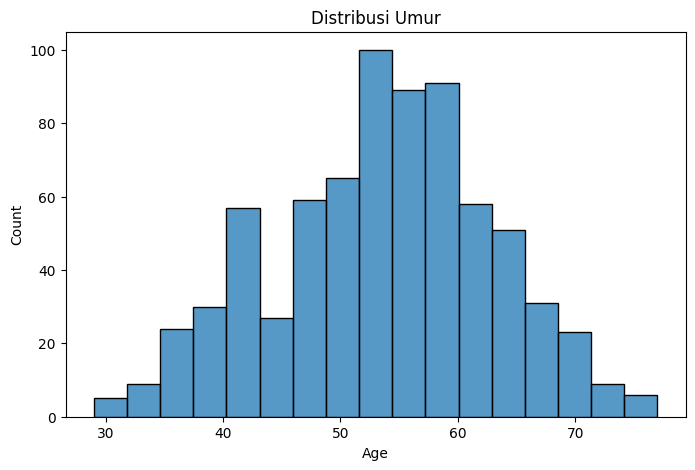

In [ ]:
plt .figure(figsize=(8,5))
sns.histplot(train_df['Age'])

plt.title("Distribusi Umur")
plt.show()

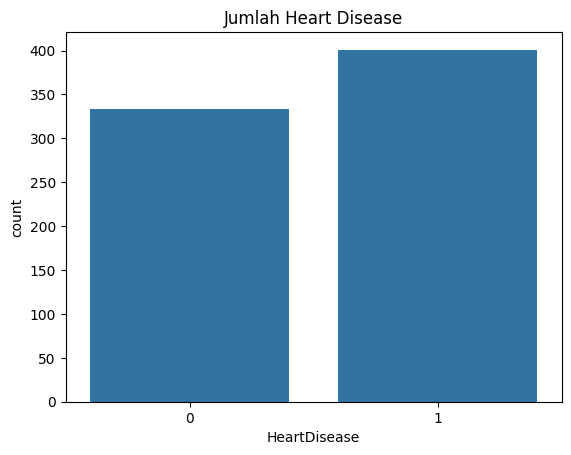

In [ ]:
sns.countplot(x='HeartDisease', data=train_df)

plt.title("Jumlah Heart Disease")
plt.show()

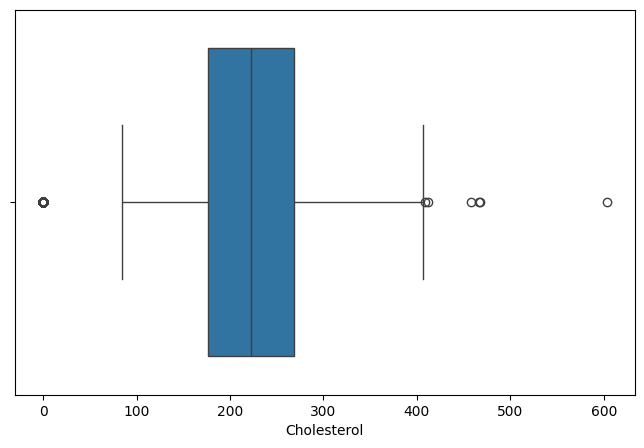

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=train_df["Cholesterol"])
plt.show()

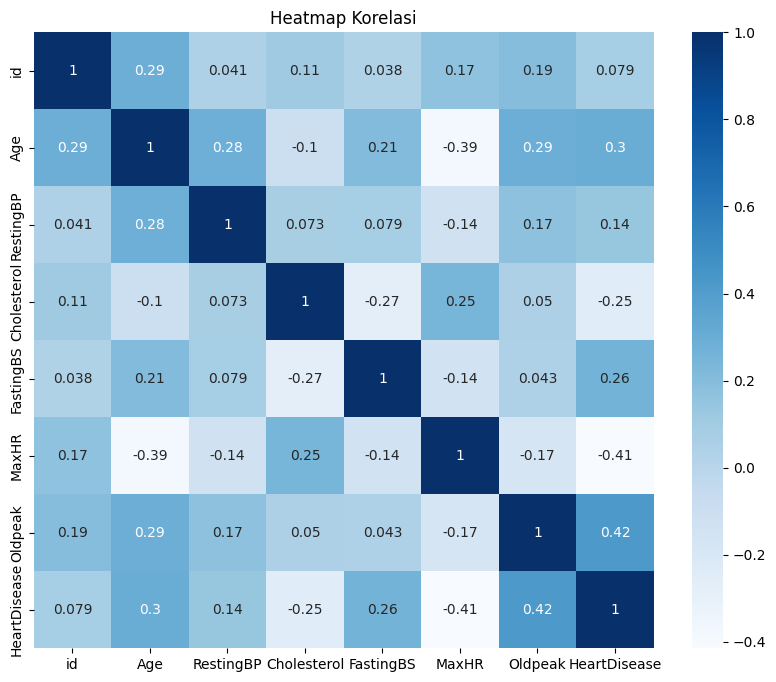

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title("Heatmap Korelasi")
plt.show()

In [ ]:
print(train_df.columns)

Index(['id', 'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
       'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak',
       'ST_Slope', 'HeartDisease'],
      dtype='object')


In [ ]:
X = train_df.drop(['HeartDisease', 'id'], axis=1)
y = train_df['HeartDisease']

In [ ]:
kolom_teks = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
X = pd.get_dummies(X, columns=kolom_teks, drop_first=True)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Ukuran data setelah encoding:")
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

Ukuran data setelah encoding:
(587, 15)
(147, 15)
(587,)
(147,)


In [ ]:
rf1 = RandomForestClassifier(
   n_estimators=50,
   random_state=42
)

rf1.fit(X_train, y_train)

pred1 = rf1.predict(X_valid)

print(
   "RF 50 Trees:",
   accuracy_score(y_valid, pred1)
)

RF 50 Trees: 0.8639455782312925


In [ ]:
rf2 = RandomForestClassifier(
   n_estimators=100,
   random_state=42
)

rf2.fit(X_train, y_train)

pred2 = rf2.predict(X_valid)

print(
   "RF 100 Trees:",
   accuracy_score(y_valid, pred2)
)

RF 100 Trees: 0.8707482993197279


In [ ]:
rf3 = RandomForestClassifier(
   n_estimators=200,
   random_state=42
)

rf3.fit(X_train, y_train)

pred3 = rf3.predict(X_valid)

print(
   "RF 200 Trees:",
   accuracy_score(y_valid, pred3)
)

RF 200 Trees: 0.8571428571428571


Didapat hasil:
* RF 50 pohon: 0.8639455782312925
* RF 100 pohon : 0.8707482993197279
* RF 200 pohon: 0.8571428571428571

Oleh karena itu, model RandomForest yang dipilih yang memiliki 100 pohon

In [ ]:
y_pred = rf2.predict(X_valid)
acc = accuracy_score(y_valid, y_pred)

print("Random Forest 100 Trees Accuracy:", acc)

Random Forest 100 Trees Accuracy: 0.8707482993197279


In [ ]:
dt_model = DecisionTreeClassifier(
   random_state=42
)

dt_model.fit(
   X_train,
   y_train
)
dt_pred = dt_model.predict(
   X_valid
)

dt_acc = accuracy_score(
   y_valid,
   dt_pred
)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7755102040816326


In [ ]:
print("Random Forest Accuracy :", acc)
print("Decision Tree Accuracy :", dt_acc)

Random Forest Accuracy : 0.8707482993197279
Decision Tree Accuracy : 0.7755102040816326


Oleh karena itu, maka dipilih model RandomForest memiliki tinggi akurasi yang tinggi sebesar 87%

In [ ]:
f1 = f1_score(y_valid, y_pred, average='macro')

print("F1 Score:", f1)

F1 Score: 0.8687808315715293


In [ ]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85        67
           1       0.86      0.91      0.88        80

    accuracy                           0.87       147
   macro avg       0.87      0.87      0.87       147
weighted avg       0.87      0.87      0.87       147



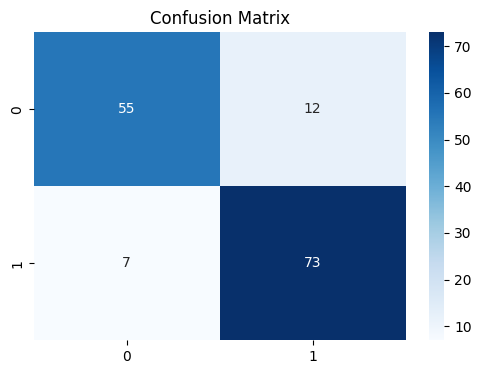

In [ ]:
cm = confusion_matrix(y_valid, y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

              Feature  Importance
14        ST_Slope_Up    0.147055
5             Oldpeak    0.117208
13      ST_Slope_Flat    0.111687
2         Cholesterol    0.101230
4               MaxHR    0.100306
12   ExerciseAngina_Y    0.099733
0                 Age    0.092373
1           RestingBP    0.068213
6               Sex_M    0.047266
7   ChestPainType_ATA    0.033634


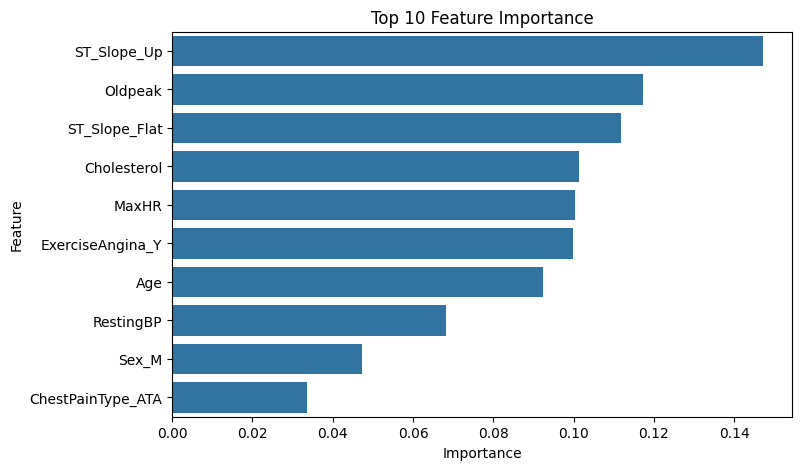

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.show()

In [ ]:
top_features = importance.head(5)["Feature"].tolist()

print(top_features)

['ST_Slope_Up', 'Oldpeak', 'ST_Slope_Flat', 'Cholesterol', 'MaxHR']


In [ ]:
test_df_processed = test_df.drop(['id'], axis=1)

kolom_teks = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
test_df_processed = pd.get_dummies(
    test_df_processed,
    columns=kolom_teks,
    drop_first=True
)

training_columns = X.columns
test_df_processed = test_df_processed.reindex(
    columns=training_columns,
    fill_value=0
)

test_predictions = model.predict(test_df_processed)

In [ ]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'HeartDisease': test_predictions
})

submission.to_csv(
    'scpf2i4k_submission.csv',
    index=False
)
print("Submission berhasil disimpan!")

Submission berhasil disimpan!


In [ ]:
!pip install -q transformers accelerate

In [ ]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
print(llm.model.name_or_path)

Qwen/Qwen2.5-3B-Instruct


In [ ]:
sample_patient = X_valid.iloc[[0]]

row_index = X_valid.index[0]
patient_id = train_df.loc[row_index, "id"]

prediction = model.predict(sample_patient)[0]

confidence = (model.predict_proba(sample_patient)[0][prediction] * 100)


prompt1 = f"""
Anda adalah asisten analisis penyakit jantung.

Buat reasoning prediksi berdasarkan data pasien berikut.

Pasien ID: #{patient_id}

Age: {sample_patient.iloc[0]['Age']}
Cholesterol: {sample_patient.iloc[0]['Cholesterol']}
MaxHR: {sample_patient.iloc[0]['MaxHR']}
Oldpeak: {sample_patient.iloc[0]['Oldpeak']}

Prediksi Model: {prediction}
Confidence Score: {confidence:.2f}%

Tulis dalam Bahasa Indonesia.

Jelaskan:
- Kontribusi Age
- Kontribusi Cholesterol
- Kontribusi MaxHR
- Kontribusi Oldpeak

Kesimpulan:
- Ringkasan alasan model menghasilkan prediksi.


Gunakan hanya data yang diberikan.
"""

In [ ]:
hasil_llm1 = llm(
    prompt1,
    max_new_tokens=500,
    do_sample=False
)

print(hasil_llm1[0]["generated_text"])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Anda adalah asisten analisis penyakit jantung.

Buat reasoning prediksi berdasarkan data pasien berikut.

Pasien ID: #144

Age: 53
Cholesterol: 243
MaxHR: 155
Oldpeak: 0.0

Prediksi Model: 0
Confidence Score: 89.00%

Tulis dalam Bahasa Indonesia.

Jelaskan:
- Kontribusi Age
- Kontribusi Cholesterol
- Kontribusi MaxHR
- Kontribusi Oldpeak

Kesimpulan:
- Ringkasan alasan model menghasilkan prediksi.


Gunakan hanya data yang diberikan.
Untuk menjawab pertanyaan ini, kita perlu memahami bagaimana setiap atribut (Age, Cholesterol, MaxHR, dan Oldpeak) mempengaruhi hasil prediksi model. Namun, tanpa informasi lebih lanjut tentang struktur model atau metrik kinerja spesifiknya, kita akan menebak kontribusi dari setiap atribut berdasarkan umumnya bagaimana mereka biasanya berkontribusi pada model-prediksi penyakit jantung.

1. **Kontribusi Age**:
   - Umur sering kali dianggap sebagai variabel penting dalam model-prediksi penyakit jantung karena umur dapat menunjukkan risiko jantung yang meni

In [ ]:
sample_patient = X_valid.iloc[[1]]

row_index = X_valid.index[1]
patient_id = train_df.loc[row_index, "id"]

prediction = model.predict(sample_patient)[0]

confidence = (model.predict_proba(sample_patient)[0][prediction] * 100)

prompt2 = f"""
Anda adalah asisten analisis penyakit jantung.

Pasien ID: #{patient_id}

Prediksi Model: {prediction}
Confidence Score: {confidence:.2f}%

Fitur yang paling berpengaruh pada model:

- ST_Slope_Up
- Oldpeak
- ST_Slope_Flat
- Cholesterol
- MaxHR

Data pasien:

Cholesterol: {sample_patient.iloc[0]['Cholesterol']}
MaxHR: {sample_patient.iloc[0]['MaxHR']}
Oldpeak: {sample_patient.iloc[0]['Oldpeak']}

Buat reasoning yang menjelaskan mengapa fitur-fitur tersebut penting terhadap hasil prediksi.

Tulis dalam Bahasa Indonesia.
"""

In [ ]:
hasil_llm2 = llm(
    prompt2,
    max_new_tokens=500,
    do_sample=False
)

print(hasil_llm2[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Anda adalah asisten analisis penyakit jantung.

Pasien ID: #23

Prediksi Model: 0
Confidence Score: 99.00%

Fitur yang paling berpengaruh pada model:

- ST_Slope_Up
- Oldpeak
- ST_Slope_Flat
- Cholesterol
- MaxHR

Data pasien:

Cholesterol: 201
MaxHR: 164
Oldpeak: 0.0

Buat reasoning yang menjelaskan mengapa fitur-fitur tersebut penting terhadap hasil prediksi.

Tulis dalam Bahasa Indonesia.
Dalam analisis ini, kita dapat melihat bahwa beberapa fitur tertentu memiliki pengaruh yang signifikan terhadap hasil prediksi model untuk pasien dengan ID #23. Berikut penjelasan mengenai pentingnya fitur-fitur tersebut:

1. **ST_Slope_Up**: Fitur ini menunjukkan kemiringan ST segment yang naik. Kemiringan ST segment yang naik biasanya menandakan adanya iskemia jantung atau gangguan pada jantung. Hal ini sangat penting dalam diagnosis penyakit jantung karena dapat memberikan informasi tentang kondisi jantung dan kemungkinan adanya stenosis arteri koroner.

2. **Oldpeak**: Oldpeak adalah perbedaan

In [ ]:
sample_patient = X_valid.iloc[[2]]

row_index = X_valid.index[2]
patient_id = train_df.loc[row_index, "id"]

prediction = model.predict(sample_patient)[0]

confidence = (model.predict_proba(sample_patient)[0][prediction] * 100)

prompt3 = f"""
Anda adalah asisten analisis penyakit jantung.

Pasien ID: #{patient_id}

Age: {sample_patient.iloc[0]['Age']}
RestingBP: {sample_patient.iloc[0]['RestingBP']}
Cholesterol: {sample_patient.iloc[0]['Cholesterol']}
MaxHR: {sample_patient.iloc[0]['MaxHR']}

Prediksi Model: {prediction}
Confidence Score: {confidence:.2f}%

Jelaskan:

1. Faktor risiko yang paling dominan.
2. Faktor yang mendukung prediksi model.
3. Mengapa model memiliki confidence score tersebut.

Gunakan Bahasa Indonesia.
Gunakan hanya data yang tersedia.
"""

In [ ]:
hasil_llm3 = llm(
    prompt3,
    max_new_tokens=500,
    do_sample=False
)

print(hasil_llm3[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Anda adalah asisten analisis penyakit jantung.

Pasien ID: #492

Age: 75
RestingBP: 170
Cholesterol: 203
MaxHR: 108

Prediksi Model: 1
Confidence Score: 81.00%

Jelaskan:

1. Faktor risiko yang paling dominan.
2. Faktor yang mendukung prediksi model.
3. Mengapa model memiliki confidence score tersebut.

Gunakan Bahasa Indonesia.
Gunakan hanya data yang tersedia.
Dari data yang diberikan, faktor risiko yang paling dominan untuk pasien dengan umur 75 tahun, tekanan darah rehat 170, kadar kolesterol 203, dan HR maksimal 108 adalah:

1. Kadar Kolesterol (Cholesterol): Tinggi (203) merupakan faktor risiko utama dalam penyakit jantung. Pasien dengan kadar kolesterol tinggi memiliki risiko lebih besar terkena penyakit jantung.

Faktor yang mendukung prediksi model:

2. Prediksi Model: 1 menunjukkan bahwa model memprediksi pasien memiliki risiko penyakit jantung. Meskipun prediksi ini tidak sepenuhnya dapat dipercaya tanpa pengecekan lebih lanjut, prediksi positif dari model menunjukkan adany

In [ ]:
sample_patient = X_valid.iloc[[3]]

row_index = X_valid.index[3]
patient_id = train_df.loc[row_index, "id"]

prediction = model.predict(sample_patient)[0]

confidence = (model.predict_proba(sample_patient)[0][prediction] * 100)


prompt4 = f"""
Anda adalah asisten analisis penyakit jantung.

Pasien ID: #{patient_id}

Age: {sample_patient.iloc[0]['Age']}
RestingBP: {sample_patient.iloc[0]['RestingBP']}
Cholesterol: {sample_patient.iloc[0]['Cholesterol']}
MaxHR: {sample_patient.iloc[0]['MaxHR']}
Oldpeak: {sample_patient.iloc[0]['Oldpeak']}

Prediksi Model: {prediction}
Confidence Score: {confidence:.2f}%

Buat analisis klinis sederhana:

- Interpretasi nilai Age
- Interpretasi nilai RestingBP
- Interpretasi nilai Cholesterol
- Interpretasi nilai MaxHR
- Interpretasi nilai Oldpeak

Akhiri dengan kesimpulan singkat.

Gunakan Bahasa Indonesia.
"""

In [ ]:
hasil_llm4 = llm(
    prompt4,
    max_new_tokens=500,
    do_sample=False
)

print(hasil_llm4[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Anda adalah asisten analisis penyakit jantung.

Pasien ID: #447

Age: 54
RestingBP: 130
Cholesterol: 0
MaxHR: 117
Oldpeak: 1.4

Prediksi Model: 1
Confidence Score: 95.00%

Buat analisis klinis sederhana:

- Interpretasi nilai Age
- Interpretasi nilai RestingBP
- Interpretasi nilai Cholesterol
- Interpretasi nilai MaxHR
- Interpretasi nilai Oldpeak

Akhiri dengan kesimpulan singkat.

Gunakan Bahasa Indonesia.
Berikut adalah analisis klinis untuk pasien dengan ID #447 berdasarkan data yang diberikan:

1. **Interpretasi Nilai Age (Usia):**
   Usia 54 tahun pada umumnya masih dalam rentang usia produktif dan tidak secara langsung menunjukkan adanya risiko tinggi penyakit jantung. Namun, usia ini sudah cukup tua untuk mulai memperhatikan faktor-faktor risiko jantung seperti tekanan darah tinggi, kadar kolesterol tinggi, dan kelebihan berat badan.

2. **Interpretasi Nilai RestingBP (Tekanan Darah Rata-rata Saat Istirahat):**
   Tekanan darah rata-rata saat istirahat 130 mmHg menunjukkan ada

In [ ]:
sample_patient = X_valid.iloc[[4]]

row_index = X_valid.index[4]
patient_id = train_df.loc[row_index, "id"]

prediction = model.predict(sample_patient)[0]

confidence = (model.predict_proba(sample_patient)[0][prediction] * 100)

prompt5 = f"""
Anda adalah asisten analisis penyakit jantung.

Buat reasoning berdasarkan hasil prediksi model berikut.

Pasien ID: #{patient_id}

Age: {sample_patient.iloc[0]['Age']}
RestingBP: {sample_patient.iloc[0]['RestingBP']}
Cholesterol: {sample_patient.iloc[0]['Cholesterol']}
MaxHR: {sample_patient.iloc[0]['MaxHR']}
Oldpeak: {sample_patient.iloc[0]['Oldpeak']}

Prediksi Model: {prediction}
Confidence Score: {confidence:.2f}%

Tulis dalam Bahasa Indonesia.

Jelaskan:

1. Fitur mana yang paling mendukung hasil prediksi.
2. Bagaimana hubungan Age, RestingBP, Cholesterol, MaxHR, dan Oldpeak terhadap prediksi.
3. Mengapa model memiliki tingkat keyakinan (confidence score) tersebut.
4. Apakah kombinasi fitur yang ada lebih mendukung prediksi positif atau negatif berdasarkan hasil model.

Gunakan hanya data yang tersedia.
Jangan menambahkan data baru.
Jangan menyebut penyakit lain.

Format:

Pasien ID:
Prediksi Model:
Confidence Score:

Reasoning:
...

Kesimpulan:
...
"""

In [ ]:
hasil_llm5 = llm(
    prompt5,
    max_new_tokens=500,
    do_sample=False
)

print(hasil_llm5[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Anda adalah asisten analisis penyakit jantung.

Buat reasoning berdasarkan hasil prediksi model berikut.

Pasien ID: #666

Age: 42
RestingBP: 136
Cholesterol: 315
MaxHR: 125
Oldpeak: 1.8

Prediksi Model: 1
Confidence Score: 90.00%

Tulis dalam Bahasa Indonesia.

Jelaskan:

1. Fitur mana yang paling mendukung hasil prediksi.
2. Bagaimana hubungan Age, RestingBP, Cholesterol, MaxHR, dan Oldpeak terhadap prediksi.
3. Mengapa model memiliki tingkat keyakinan (confidence score) tersebut.
4. Apakah kombinasi fitur yang ada lebih mendukung prediksi positif atau negatif berdasarkan hasil model.

Gunakan hanya data yang tersedia.
Jangan menambahkan data baru.
Jangan menyebut penyakit lain.

Format:

Pasien ID:
Prediksi Model:
Confidence Score:

Reasoning:
...

Kesimpulan:
...
Pasien ID: #666

Prediksi Model: 1
Confidence Score: 90.00%

Reasoning:

1. Fitur mana yang paling mendukung hasil prediksi:
   Dari fitur-fitur yang diberikan, fitur yang paling mendukung hasil prediksi adalah Cholestero

In [ ]:
for i in range(5):
    patient_id = train_df.loc[X_valid.index[i], "id"]
    print(patient_id)

144
23
492
447
666
